In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


df = pd.read_csv("/scratch/gpfs/jp7427/FVvsSD/sinus-timing/timing_results.csv")

SUBROUTINES = (
    "RK", # needs to be computed
    "compute_dt",
    "boundary_conditions",
    "stencil_sweep",
    "einsum",
    "primitive_conservative",
    "riemann_solver",
    "transpose",
    "candidate_solution",
    "detect_troubles",
    "fallback_fluxes",
    "assign_fluxes",
)

TARGET_NDOF = 3072

ROUTINE_LABELS = {
    "compute_dt": "dt",
    "primitive_conservative": "prim/cons",
    "boundary_conditions": "BCs",
    "stencil_sweep": "stencils",
    "einsum": "einsums",
    "riemann_solver": "Riemann",
    "transpose": "transposes",
    "mood_loop": "MOOD loop",
    "candidate_solution": "candidate solution",
    "detect_troubles": "detect troubles",
    "fallback_fluxes": "fallback fluxes",
    "assign_fluxes": "correct fluxes",
    "RK": "RK"
}

df["RK_time_per_step"] = df["compute_dudt_time_per_step"] + (df["update_unew_time_per_step"] - df["f_time_per_step"])
df["RK_ncalls_per_step"] = df["compute_dudt_ncalls_per_step"]
breakdown_cols = [f"{cat}_time_per_step" for cat in SUBROUTINES]
df["timed_per_step"] = df[breakdown_cols].sum(axis=1)
df["untimed_per_step"] = df["total_time_per_step"] - df["timed_per_step"]


def plot(ax, frame, quantity, **kwargs):
    if frame.empty:
        return
    ax.plot(frame.NDOF, frame[quantity], marker="o", **kwargs)

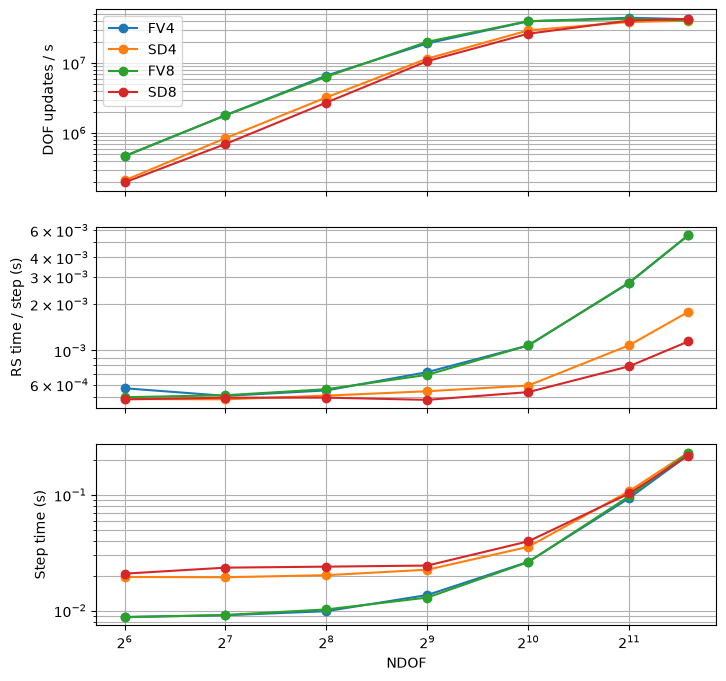

In [2]:
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(8, 8))
axs[2].set_xlabel("NDOF")
axs[0].set_ylabel("DOF updates / s")
axs[1].set_ylabel("RS time / step (s)")
axs[2].set_ylabel("Step time (s)")
axs[0].set_xscale("log", base=2)
for ax in axs:
    ax.set_yscale("log")

for scheme, p, label in (("FV", 3, "FV4"), ("SD", 3, "SD4"), ("FV", 7, "FV8"), ("SD", 7, "SD8")):
    frame = df[(df.scheme == scheme) & (df.p == p)].sort_values("NDOF")
    plot(axs[0], frame, "update_rate", label=label)
    plot(axs[1], frame, "riemann_solver_time_per_step", label=label)
    plot(axs[2], frame, "total_time_per_step", label=label)

for ax in axs:
    ax.grid(which="both")
axs[0].legend()

fig.savefig("update-rates.pdf", bbox_inches="tight")

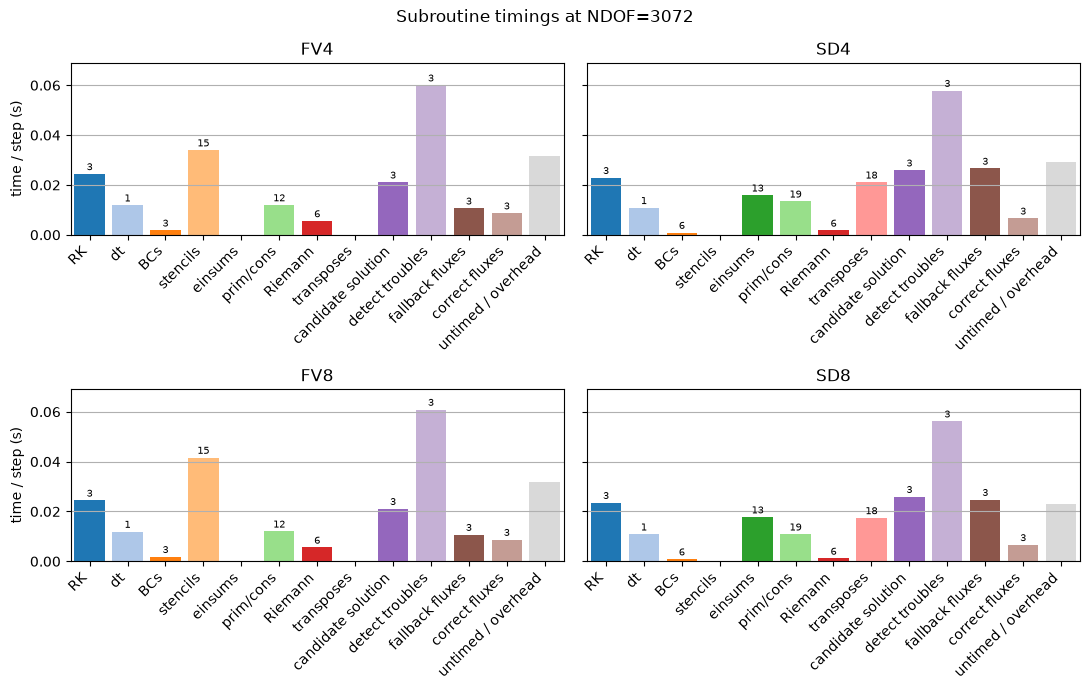

In [3]:
fig, axs = plt.subplots(2, 2, sharey=True, figsize=(11, 7))
fig.suptitle(f"Subroutine timings at NDOF={TARGET_NDOF}")

cases = (("FV", 3, "FV4"), ("SD", 3, "SD4"), ("FV", 7, "FV8"), ("SD", 7, "SD8"))
bar_cats = SUBROUTINES + ("untimed_per_step",)
bar_labels = [ROUTINE_LABELS.get(cat, "untimed / overhead") for cat in bar_cats]
colors = list(plt.get_cmap("tab20").colors[: len(SUBROUTINES)]) + ["0.85"]
SHOW_NCALLS_IN_BARS = True


def ncalls_label(ncalls):
    if pd.isna(ncalls) or ncalls <= 0:
        return ""
    if np.isclose(ncalls, round(ncalls)):
        return str(int(round(ncalls)))
    return f"{ncalls:.2f}"

for ax, (scheme, p, title) in zip(axs.flat, cases):
    frame = df[(df.scheme == scheme) & (df.p == p) & (df.NDOF == TARGET_NDOF)]
    x = np.arange(len(bar_cats))
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, rotation=45, ha="right")

    if not frame.empty:
        row = frame.iloc[-1]
        values = [row[f"{cat}_time_per_step"] for cat in SUBROUTINES]
        values.append(row["untimed_per_step"])
        bars = ax.bar(x, values, color=colors)
        if SHOW_NCALLS_IN_BARS:
            ncalls = [row.get(f"{cat}_ncalls_per_step", np.nan) for cat in SUBROUTINES]
            ncalls.append(np.nan)
            for bar, ncall in zip(bars, ncalls):
                height = bar.get_height()
                label = ncalls_label(ncall)
                if not label or not np.isfinite(height) or height <= 0:
                    continue
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height + 2.5e-3,# height / 2,
                    label,
                    ha="center",
                    va="center",
                    #rotation=90,
                    fontsize=7,
                    clip_on=True,
                )
    else:
        ax.text(0.5, 0.5, "missing NDOF", ha="center", va="center", transform=ax.transAxes)

    ax.set_xlim(-0.5, len(bar_cats) - 0.5)
    ax.grid(axis="y")

for ax in axs[:, 0]:
    ax.set_ylabel("time / step (s)")
    bottom, top = ax.get_ylim()
    new_top = top + 2.5e-3
    ax.set_ylim([bottom, new_top])

fig.tight_layout()
fig.savefig("subroutine-times.pdf", bbox_inches="tight")